# SRM Filter Analysis on JPG Images

In [1]:
import sys
sys.path.insert(0, '/home/bryanchang/face-tamper-inference')

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

from src.models.srm_utils import SRMFilter, _build_srm_kernels

## 1. Visualise the 30 SRM kernels

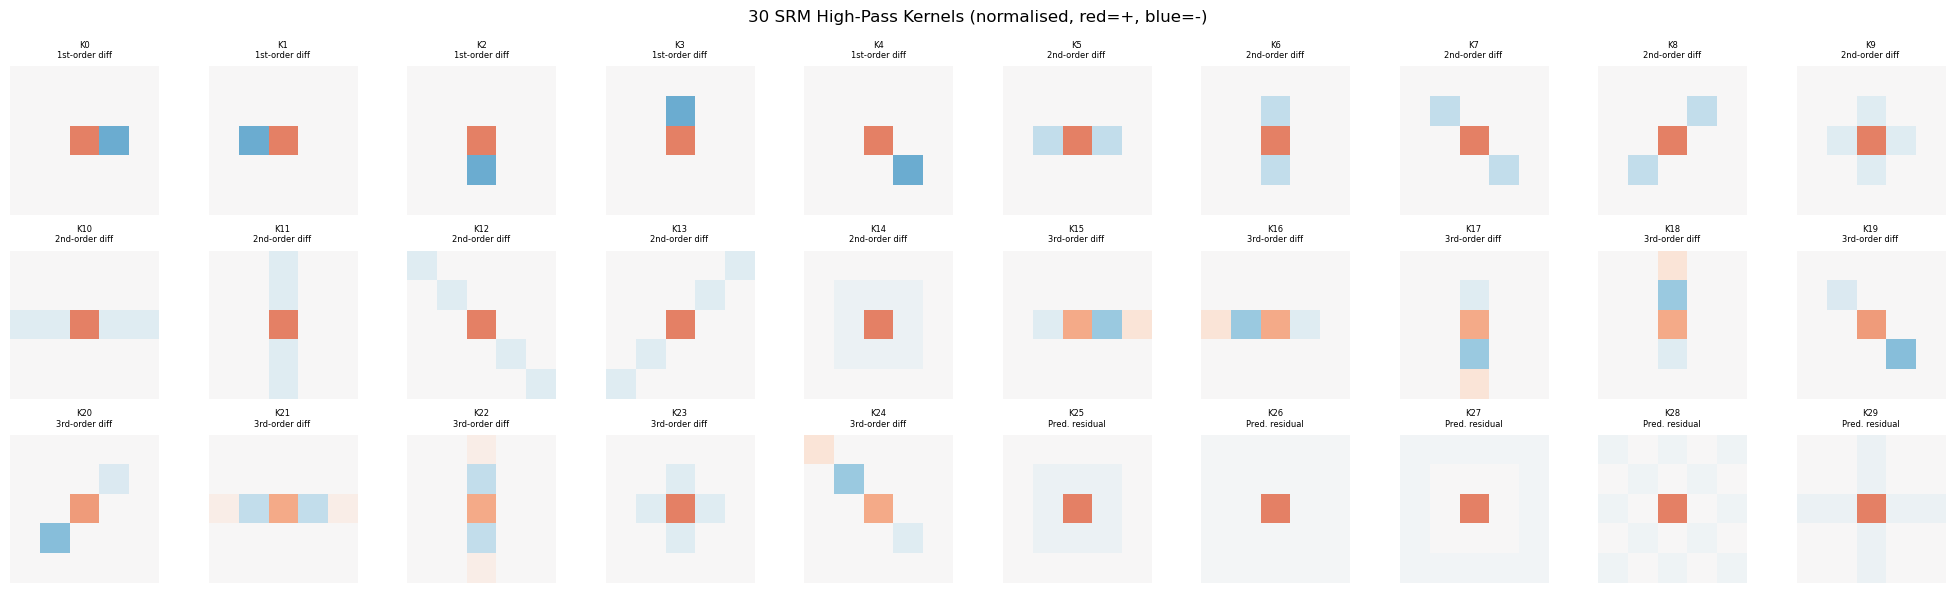

Kernel shape: (30, 5, 5), value range: [-0.500, 0.500]


In [2]:
kernels = _build_srm_kernels()  # (30, 5, 5)

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
kernel_groups = (
    ['1st-order diff'] * 5 +
    ['2nd-order diff'] * 10 +
    ['3rd-order diff'] * 10 +
    ['Pred. residual'] * 5
)
for i, ax in enumerate(axes.flat):
    im = ax.imshow(kernels[i], cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f'K{i}\n{kernel_groups[i]}', fontsize=6)
    ax.axis('off')

plt.suptitle('30 SRM High-Pass Kernels (normalised, red=+, blue=-)', fontsize=12)
plt.tight_layout()
plt.show()
print(f"Kernel shape: {kernels.shape}, value range: [{kernels.min():.3f}, {kernels.max():.3f}]")

## 2. Load a JPG and run SRMFilter

Input : torch.Size([1, 3, 512, 512])
Output: torch.Size([1, 30, 512, 512])
Noise map range: [-0.2351, 0.4654]


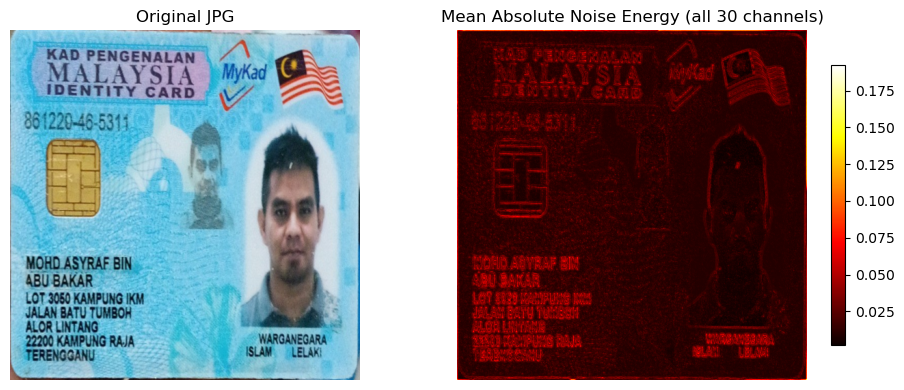

In [3]:
# ---- change this path to any JPG you want to analyse ----
IMAGE_PATH = '/home/bryanchang/face-tamper-inference/mykad_front_ocr.jpg'
# ----------------------------------------------------------

transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),          # → [0, 1], shape (3, H, W)
])

img_pil = Image.open(IMAGE_PATH).convert('RGB')
img_tensor = transform(img_pil).unsqueeze(0)   # (1, 3, 512, 512)

srm = SRMFilter()
with torch.no_grad():
    noise_maps = srm(img_tensor)               # (1, 30, 512, 512)

print(f"Input : {img_tensor.shape}")
print(f"Output: {noise_maps.shape}")
print(f"Noise map range: [{noise_maps.min():.4f}, {noise_maps.max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_pil.resize((512, 512)))
axes[0].set_title('Original JPG')
axes[0].axis('off')
# Show energy across all 30 channels (mean absolute residual)
energy = noise_maps[0].abs().mean(0).numpy()
im = axes[1].imshow(energy, cmap='hot')
axes[1].set_title('Mean Absolute Noise Energy (all 30 channels)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()

## 3. Browse individual noise channels

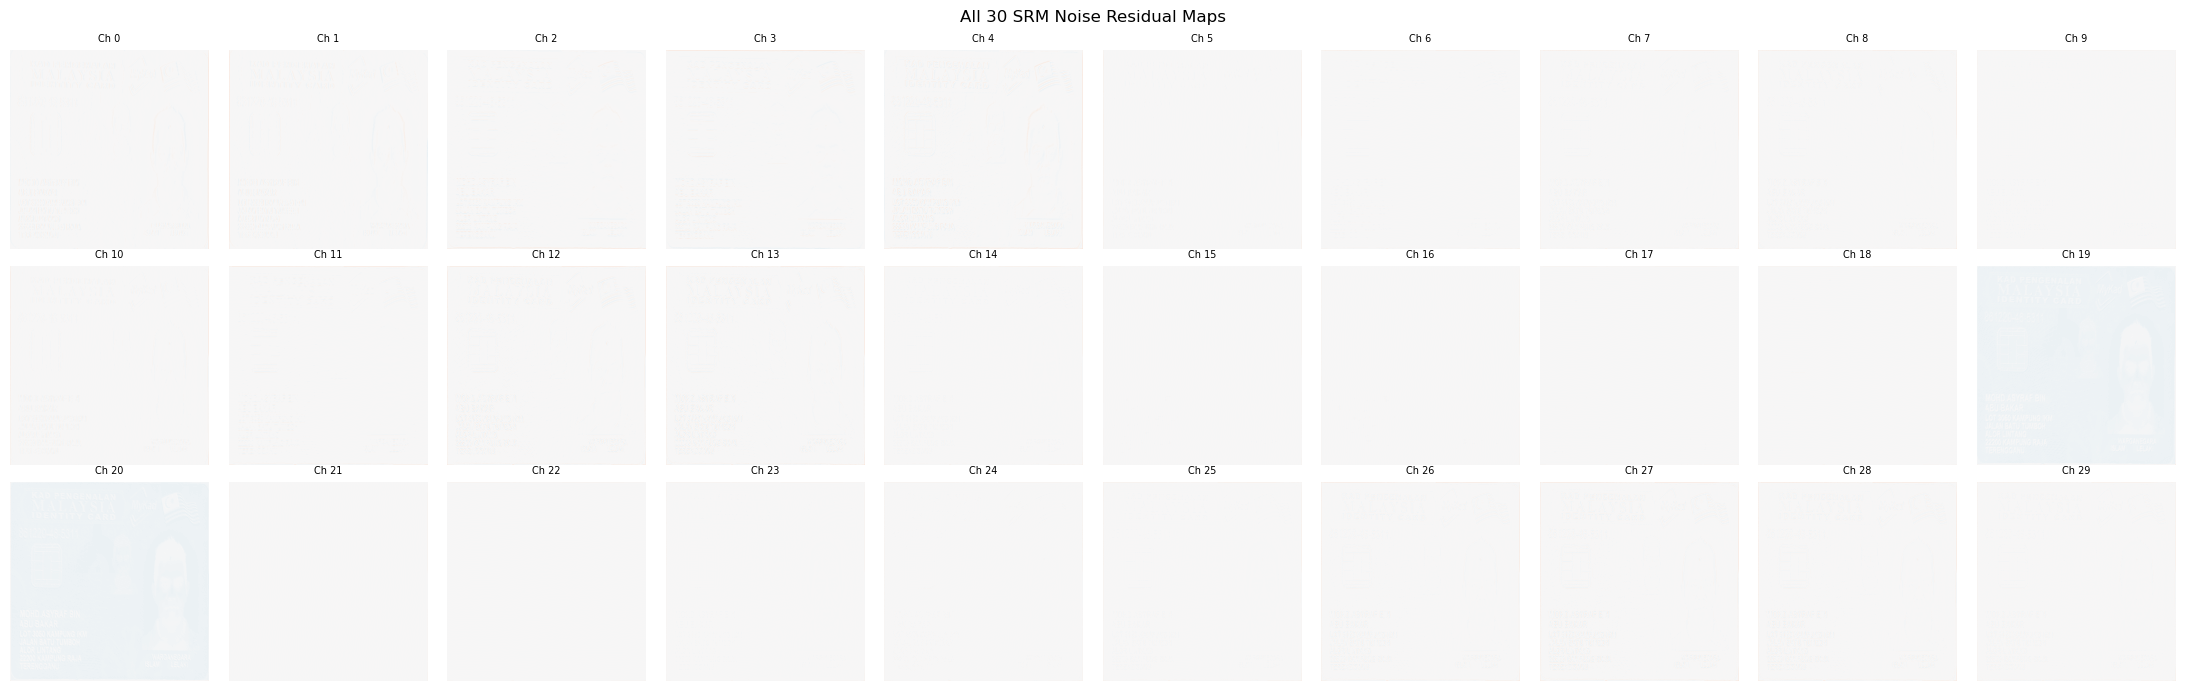

In [4]:
fig, axes = plt.subplots(3, 10, figsize=(22, 7))
for i, ax in enumerate(axes.flat):
    ch = noise_maps[0, i].numpy()
    ax.imshow(ch, cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_title(f'Ch {i}', fontsize=7)
    ax.axis('off')
plt.suptitle('All 30 SRM Noise Residual Maps', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Per-channel statistics — spot anomalous regions

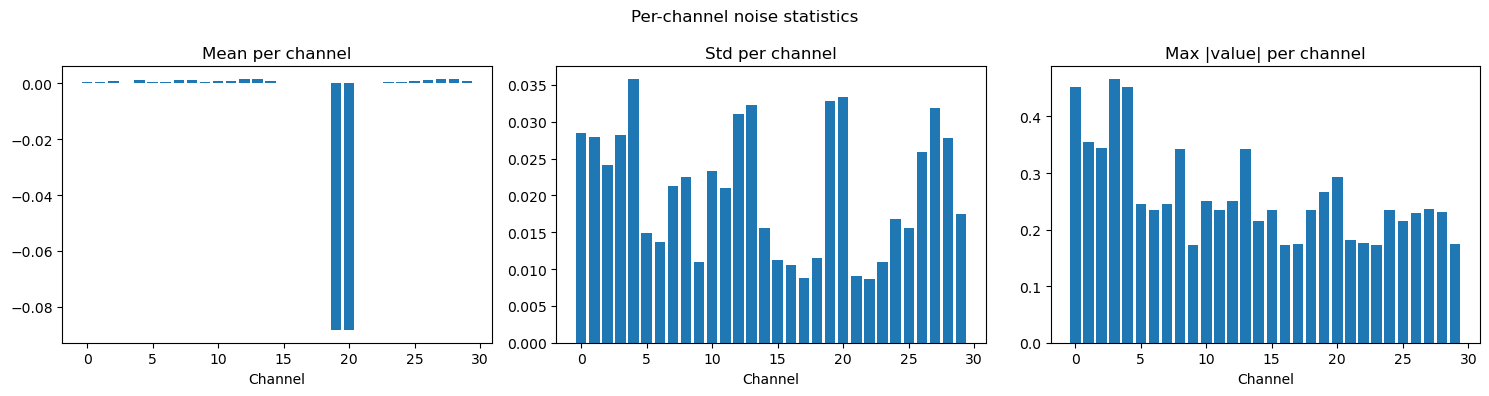

Top-5 highest-energy channels: [ 4 20 19 13 27]


In [5]:
maps = noise_maps[0].numpy()  # (30, H, W)
means = maps.mean(axis=(1, 2))
stds  = maps.std(axis=(1, 2))
maxabs = np.abs(maps).max(axis=(1, 2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(range(30), means);  axes[0].set_title('Mean per channel');  axes[0].set_xlabel('Channel')
axes[1].bar(range(30), stds);   axes[1].set_title('Std per channel');   axes[1].set_xlabel('Channel')
axes[2].bar(range(30), maxabs); axes[2].set_title('Max |value| per channel'); axes[2].set_xlabel('Channel')
plt.suptitle('Per-channel noise statistics')
plt.tight_layout()
plt.show()

# Channels with highest energy (most discriminative for tampering)
top5 = np.argsort(stds)[::-1][:5]
print("Top-5 highest-energy channels:", top5)

## 5. Compare two images side-by-side (e.g. authentic vs tampered)

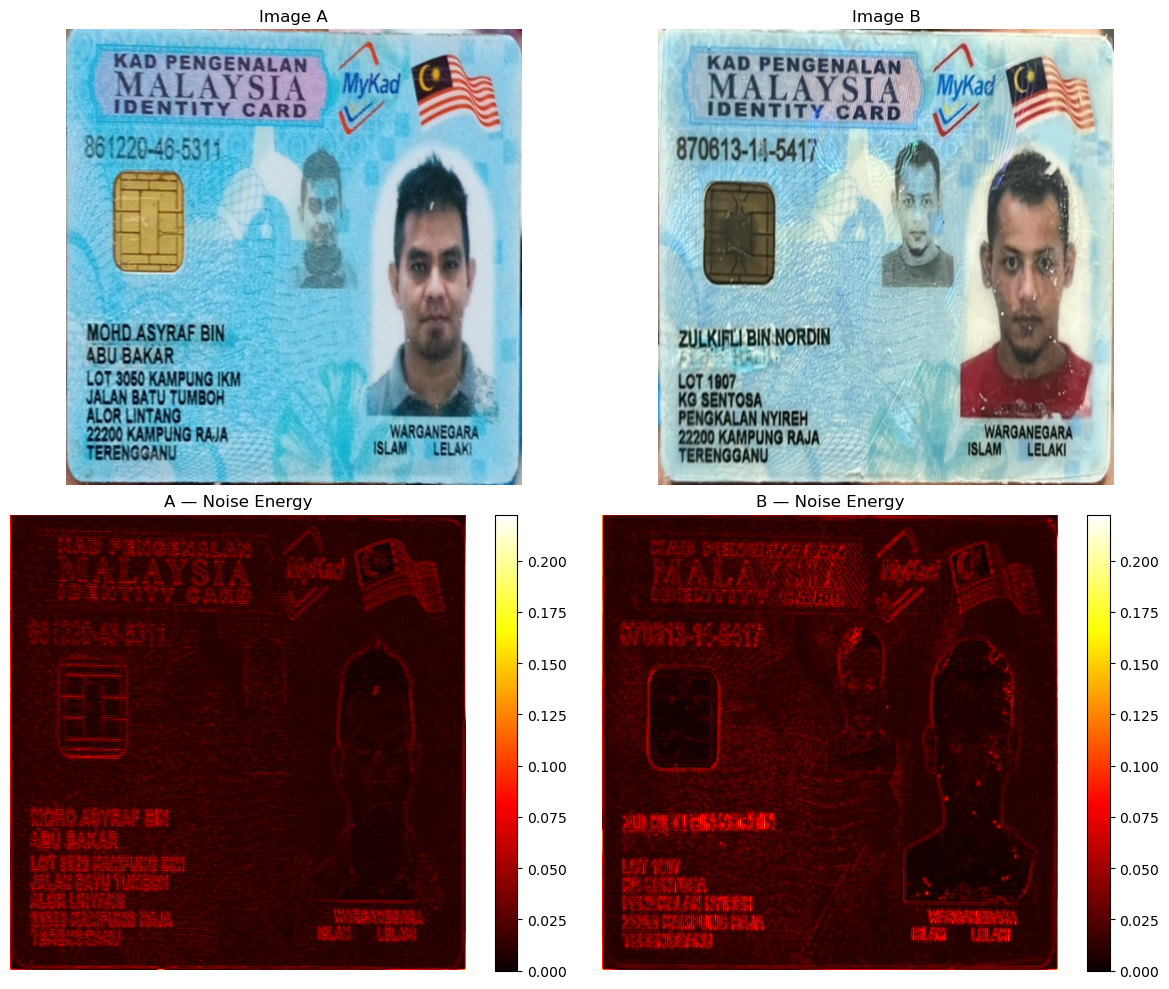

A mean energy: 0.0161  |  B mean energy: 0.0176


In [ ]:
def load_and_run_srm(path, size=512):
    pil = Image.open(path).convert('RGB')
    t = T.Compose([T.Resize((size, size)), T.ToTensor()])
    tensor = t(pil).unsqueeze(0)
    with torch.no_grad():
        noise = srm(tensor)
    return pil, noise

# ---- set your two image paths here ----
PATH_A = '/home/bryanchang/face-tamper-inference/mykad_front_ocr.jpg'
PATH_B = 'e7e985ed-712e-42c1-90f5-80a2d51c66c8.jpg'
# ----------------------------------------

pil_a, noise_a = load_and_run_srm(PATH_A)
pil_b, noise_b = load_and_run_srm(PATH_B)

energy_a = noise_a[0].abs().mean(0).numpy()
energy_b = noise_b[0].abs().mean(0).numpy()

vmax = max(energy_a.max(), energy_b.max())

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(pil_a.resize((512, 512))); axes[0, 0].set_title('Image A'); axes[0, 0].axis('off')
axes[0, 1].imshow(pil_b.resize((512, 512))); axes[0, 1].set_title('Image B'); axes[0, 1].axis('off')
im = axes[1, 0].imshow(energy_a, cmap='hot', vmin=0, vmax=vmax)
axes[1, 0].set_title('A — Noise Energy'); axes[1, 0].axis('off'); plt.colorbar(im, ax=axes[1, 0])
im = axes[1, 1].imshow(energy_b, cmap='hot', vmin=0, vmax=vmax)
axes[1, 1].set_title('B — Noise Energy'); axes[1, 1].axis('off'); plt.colorbar(im, ax=axes[1, 1])
plt.tight_layout()
plt.show()

print(f"A mean energy: {energy_a.mean():.4f}  |  B mean energy: {energy_b.mean():.4f}")